# FIS205 TAREA 2
## Ignacio Díaz
### Problema 1

### a) Problema directo e inverso

**Problema directo.** Dado el conjunto de parámetros físicos $\theta = (\gamma, k)$, el problema directo consiste en calcular la respuesta del sistema. Para el oscilador armónico amortiguado

$$\ddot{x}(t) + \gamma\,\dot{x}(t) + k\,x(t) = 0, \qquad x(0)=1,\;\dot{x}(0)=0,$$

basta resolver la EDO (analítica o numéricamente) para obtener la señal $x(t)$. Por ejemplo, en el caso subamortiguado ($\gamma^2 < 4k$) la solución es

$$x(t) = e^{-\gamma t/2}\left[\cos(\omega_d t) + \frac{\gamma}{2\omega_d}\sin(\omega_d t)\right], \qquad \omega_d = \sqrt{k - \tfrac{\gamma^2}{4}}.$$

Es un problema **bien planteado**: la solución existe, es única y depende de forma estable de los datos.

**Problema inverso.** Es la operación contraria: a partir de la señal observada $\mathbf{x} = (x(t_1),\dots,x(t_{N_t}))$ se busca inferir los parámetros $\theta = (\gamma, k)$ que la generaron.

**Dificultad del problema inverso.** Aunque el mapeo directo $(\gamma,k)\mapsto x(t)$ es sencillo y explícito, el mapeo inverso $x(t)\mapsto(\gamma,k)$ **no** lo es:

1. **No hay fórmula cerrada** para despejar $(\gamma,k)$ desde $x(t)$; hay que resolver un problema de ajuste/optimización.
2. **Puede ser mal planteado** no se garantiza unicidad ni estabilidad. Parámetros distintos pueden producir señales casi indistinguibles, especialmente con muestreo escaso.
3. **Sensibilidad al ruido** pequeñas perturbaciones en los datos pueden producir grandes variaciones en los parámetros estimados.

Por eso conviene atacarlo con un modelo de aprendizaje supervisado que **aproxime** ese mapeo inverso a partir de muchos ejemplos.

### Aprendizaje supervisado

En aprendizaje **supervisado** se dispone de un conjunto de pares entrada–salida

$$\{(\mathbf{x}_i, \theta_i)\}_{i=1}^{N},$$

donde $\mathbf{x}_i$ es la señal observada (la **entrada**) y $\theta_i = (\gamma_i, k_i)$ son las **etiquetas** (la salida correcta). El objetivo es aprender una función $f_\phi$ (con parámetros entrenables $\phi$) tal que $f_\phi(\mathbf{x}_i) \approx \theta_i$.

**¿Es necesario conocer las etiquetas?** Sí. El término "supervisado" se refiere justamente a que durante el entrenamiento el modelo conoce la respuesta correcta $\theta_i$ de cada ejemplo, y ajusta sus parámetros comparando su predicción $\hat\theta_i = f_\phi(\mathbf{x}_i)$ con la etiqueta real $\theta_i$. Sin etiquetas no existe una referencia con la cual medir y corregir el error, y no se puede entrenar de forma supervisada.

La ventaja en este problema inverso es que las etiquetas **se obtienen resolviendo el problema directo**: elegimos parámetros conocidos $(\gamma_i, k_i)$, simulamos la EDO para generar su señal $\mathbf{x}_i$, y obtenemos así un conjunto de datos etiquetado de forma exacta y a bajo costo.

### Conjuntos de entrenamiento y validación (train / test)

Los datos disponibles se separan en al menos dos subconjuntos disjuntos:

- **Entrenamiento (train):** se usa para ajustar los parámetros del modelo (minimizar la función de pérdida).
- **Prueba (test):** se reserva y **no** se usa durante el entrenamiento; sirve para evaluar el desempeño del modelo sobre datos que nunca vio.

**¿Por qué se separan?** Porque lo que interesa no es que el modelo reproduzca bien los datos que ya conoce, sino que **generalice** a datos nuevos. Si se evalúa el modelo con los mismos datos de entrenamiento, la métrica resulta demasiado optimista: el modelo podría haber **memorizado** los ejemplos (sobreajuste / *overfitting*) en lugar de aprender la relación física subyacente. El conjunto de prueba actúa como una estimación honesta del error de generalización.


### Función de pérdida (MSE)

Para entrenar el modelo se necesita una medida cuantitativa, en un solo número, de qué tan lejos están las predicciones de los valores correctos. Esa medida es la **función de pérdida**, y el entrenamiento consiste en **minimizarla** ajustando los parámetros del modelo (típicamente por descenso de gradiente).

Una elección estándar es el **error cuadrático medio (MSE)**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}\left[(\gamma_i - \hat\gamma_i)^2 + (k_i - \hat k_i)^2\right],$$

donde $(\gamma_i, k_i)$ son los parámetros reales y $(\hat\gamma_i, \hat k_i)$ los predichos por el modelo.

**¿Por qué es necesaria y por qué el MSE?**

1. **Da un objetivo único y optimizable:** resume el desempeño sobre todo el conjunto en un escalar que se puede minimizar.
2. **Es diferenciable:** permite calcular gradientes y entrenar con descenso de gradiente.
3. **Penaliza más los errores grandes:** al elevar al cuadrado, los desvíos grandes pesan mucho más que los pequeños, empujando al modelo a evitarlos.
4. **Es no negativo y se anula solo en la predicción perfecta**, lo que lo hace una medida de error natural.
5. **Tiene interpretación estadística:** minimizar el MSE equivale a estimación por máxima verosimilitud cuando se supone ruido gaussiano en los datos.

En este caso, el MSE mide la distancia (euclídea, promediada sobre los $N$ ejemplos) entre los parámetros verdaderos y los estimados en el **espacio de parámetros** $\theta=(\gamma,k)$.

# Inciso B)

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Generador de números aleatorios con semilla fija
rng = np.random.default_rng(42)

#configuración
N     = 3000     # número total de señales en el dataset
Nt    = 1000     # número de puntos temporales por señal
t0    = 0.0      # tiempo inicial
tf    = 10.0     # tiempo final
sigma = 0.02     # desviación estándar del ruido gaussiano

# Malla de tiempo: la misma para todas las señales
t = np.linspace(t0, tf, Nt)

In [2]:
# La ecuación es de 2do orden:  x'' + gamma*x' + k*x = 0
# Para integrarla numéricamente la escribimos como sistema de 1er orden.
# Definimos el estado y = [x, v], donde v = x' (la velocidad).
# Entonces:
#   x' = v
#   v' = -gamma*v - k*x
def oscilador(t, y, gamma, k):
    x, v = y
    return [v, -gamma*v - k*x]

In [3]:
# Arreglos donde guardaremos los datos
X     = np.zeros((N, Nt))   # cada fila es una señal ruidosa (la entrada)
Theta = np.zeros((N, 2))    # cada fila son las etiquetas [gamma, k]

# Condiciones iniciales: x(0)=1, x'(0)=0
y0 = [1.0, 0.0]

for i in range(N):
    # 1) Sortear parámetros físicos desde distribuciones uniformes
    gamma = rng.uniform(0.05, 1.0)   # gamma  U(0.05, 1.0)
    k     = rng.uniform(1.0, 5.0)    # k  U(1.0, 5.0)

    # 2) Resolver la EDO en la malla de tiempo t
    sol = solve_ivp(oscilador, [t0, tf], y0,
                    t_eval=t,            # evaluar la solución en nuestros 1000 puntos
                    args=(gamma, k),     # pasar gamma y k a la función
                    rtol=1e-6, atol=1e-8)
    x_limpia = sol.y[0]                  # sol.y[0] es x(t); sol.y[1] sería v(t)


    ruido = rng.normal(0.0, sigma, Nt)
    X[i]     = x_limpia + ruido          # señal observada (con ruido)
    Theta[i] = [gamma, k]                # etiquetas correspondientes

print("Forma de X:", X.shape)        # (3000, 1000)
print("Forma de Theta:", Theta.shape) # (3000, 2)

Forma de X: (3000, 1000)
Forma de Theta: (3000, 2)


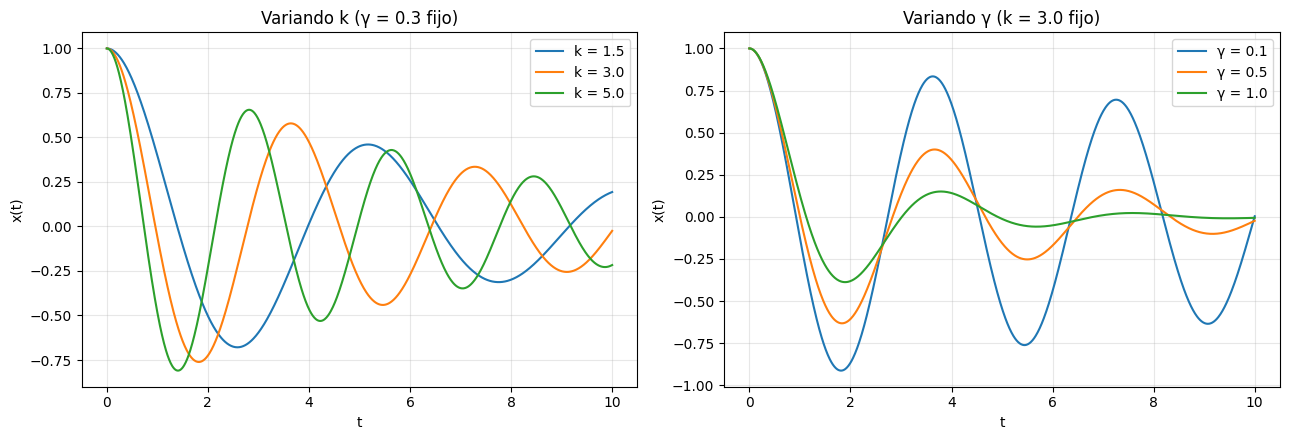

In [4]:

def señal_limpia(gamma, k):
    sol = solve_ivp(oscilador, [t0, tf], y0, t_eval=t,
                    args=(gamma, k), rtol=1e-6, atol=1e-8)
    return sol.y[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: fijamos gamma y variamos k -> efecto sobre la FRECUENCIA
for k in [1.5, 3.0, 5.0]:
    ax[0].plot(t, señal_limpia(0.3, k), label=f"k = {k}")
ax[0].set_title("Variando k (γ = 0.3 fijo)")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x(t)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# Panel derecho: fijamos k y variamos gamma -> efecto sobre el DECAIMIENTO
for g in [0.1, 0.5, 1.0]:
    ax[1].plot(t, señal_limpia(g, 3.0), label=f"γ = {g}")
ax[1].set_title("Variando γ (k = 3.0 fijo)")
ax[1].set_xlabel("t"); ax[1].set_ylabel("x(t)")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generación del dataset y discusión física

Se generaron $N = 3000$ señales. Para cada una se sortearon $\gamma \sim \mathcal{U}(0.05, 1.0)$ y $k \sim \mathcal{U}(1.0, 5.0)$, se resolvió la EDO en $t \in [0, 10]$ con $N_t = 1000$ puntos, y se agregó ruido gaussiano $\eta_j \sim \mathcal{N}(0, \sigma^2)$ con $\sigma = 0.02$. El resultado es un arreglo de señales `X` (entradas) y otro de etiquetas `Theta` $=(\gamma, k)$.

**Cómo cambian frecuencia y decaimiento.** Para el oscilador subamortiguado, la solución tiene la forma de una oscilación con amplitud que decae exponencialmente:

$$x(t) = e^{-\gamma t/2}\left[\cos(\omega_d t) + \frac{\gamma}{2\omega_d}\sin(\omega_d t)\right], \qquad \omega_d = \sqrt{k - \frac{\gamma^2}{4}}.$$

De aquí se ven dos efectos separados:

- **El parámetro $k$ controla la frecuencia.** La frecuencia angular de oscilación es $\omega_d = \sqrt{k - \gamma^2/4} \approx \sqrt{k}$. Al aumentar $k$, la señal oscila más rápido (más ciclos en el mismo intervalo de tiempo), como se observa en el panel izquierdo de la figura.

- **El parámetro $\gamma$ controla el decaimiento.** La amplitud está modulada por la envolvente $e^{-\gamma t/2}$. Al aumentar $\gamma$, esa envolvente decae más rápido y la señal se apaga antes, como muestra el panel derecho. Para $\gamma$ grande la oscilación apenas alcanza a completar unos pocos ciclos antes de extinguirse.

En los rangos elegidos siempre se cumple $\gamma^2 < 4k$, por lo que **todos** los sistemas son subamortiguados: todas las señales oscilan. Esto es deseable, porque cada señal contiene información clara tanto de la frecuencia (ligada a $k$) como de la tasa de decaimiento (ligada a $\gamma$), que es justamente lo que el modelo deberá aprender a leer para resolver el problema inverso.

# Inciso C)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor

# 80% entrenamiento, 20% validación. random_state fija la partición (reproducible).
X_train, X_test, y_train, y_test = train_test_split(
    X, Theta, test_size=0.2, random_state=0)

print("Entrenamiento:", X_train.shape, "  Validación:", X_test.shape)

Entrenamiento: (2400, 1000)   Validación: (600, 1000)


In [7]:
# 200 árboles; n_jobs=-1 usa todos los núcleos del CPU.
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)              # entrenar
pred_rf = rf.predict(X_test)         # predecir sobre el test

In [8]:
# Pipeline: primero estandariza las ENTRADAS, luego pasa al MLP.
base_mlp = make_pipeline(
    StandardScaler(),                                  # escala las entradas (la señal)
    MLPRegressor(hidden_layer_sizes=(128, 64),         # 2 capas ocultas: 128 y 64 neuronas
                 max_iter=1000,                        # iteraciones máximas de entrenamiento
                 random_state=0)
)

# TransformedTargetRegressor escala también las SALIDAS (gamma, k) durante el
# entrenamiento y "des-escala" al predecir. Esto pone a gamma y k en pie de igualdad.
mlp = TransformedTargetRegressor(regressor=base_mlp, transformer=StandardScaler())
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

In [9]:
import numpy as np

def rmse_por_parametro(y_true, y_pred):
    # columna 0 = gamma, columna 1 = k
    rmse_gamma = np.sqrt(np.mean((y_true[:, 0] - y_pred[:, 0])**2))
    rmse_k     = np.sqrt(np.mean((y_true[:, 1] - y_pred[:, 1])**2))
    return rmse_gamma, rmse_k

g_rf,  k_rf  = rmse_por_parametro(y_test, pred_rf)
g_mlp, k_mlp = rmse_por_parametro(y_test, pred_mlp)

print(f"{'Modelo':<15}{'RMSE_gamma':>12}{'RMSE_k':>12}")
print(f"{'RandomForest':<15}{g_rf:>12.4f}{k_rf:>12.4f}")
print(f"{'MLP':<15}{g_mlp:>12.4f}{k_mlp:>12.4f}")

Modelo           RMSE_gamma      RMSE_k
RandomForest         0.0156      0.0432
MLP                  0.0267      0.0819


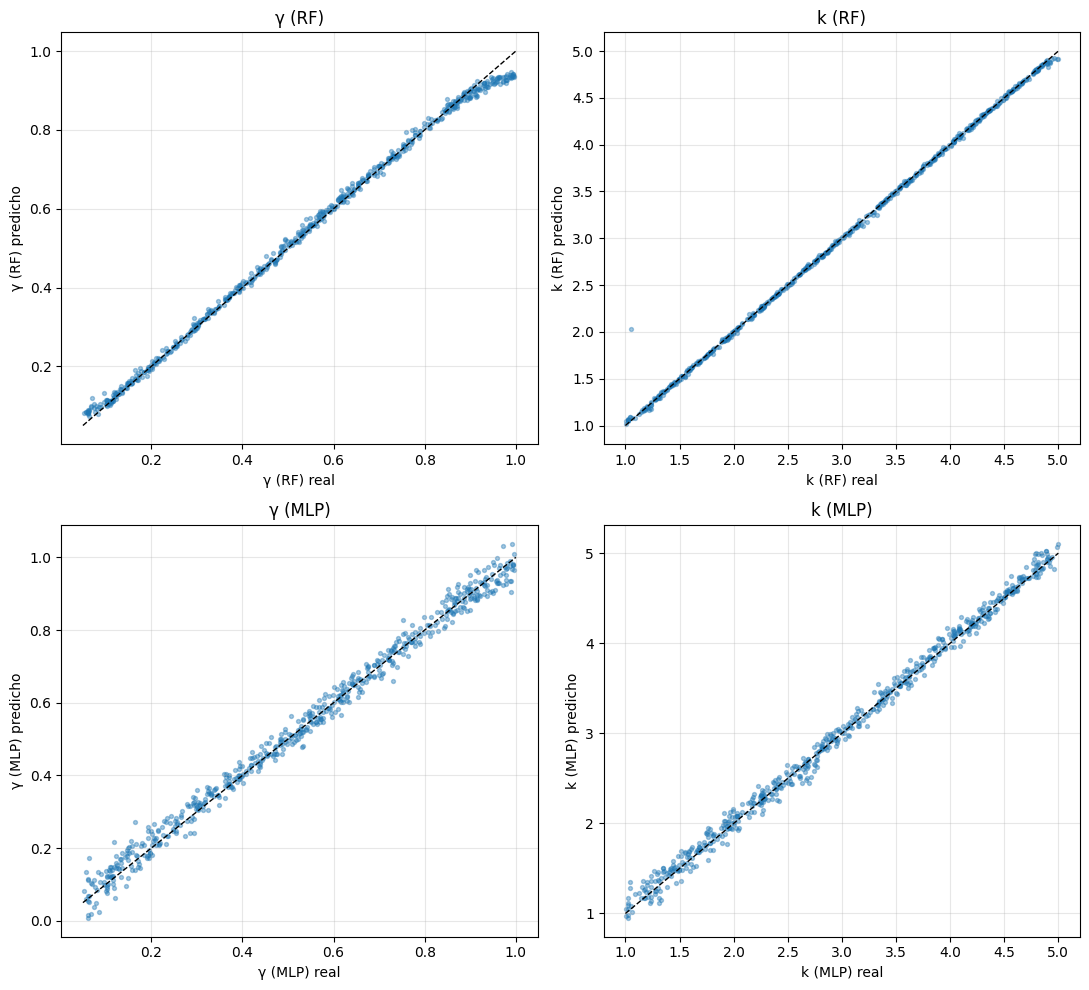

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(11, 10))

def scatter(a, real, pred, nombre, lo, hi):
    a.scatter(real, pred, s=8, alpha=0.4)
    a.plot([lo, hi], [lo, hi], 'k--', lw=1)   # diagonal = predicción perfecta
    a.set_xlabel(f"{nombre} real"); a.set_ylabel(f"{nombre} predicho")
    a.set_title(nombre); a.grid(alpha=0.3)

scatter(ax[0,0], y_test[:,0], pred_rf[:,0],  "γ (RF)",  0.05, 1.0)
scatter(ax[0,1], y_test[:,1], pred_rf[:,1],  "k (RF)",  1.0,  5.0)
scatter(ax[1,0], y_test[:,0], pred_mlp[:,0], "γ (MLP)", 0.05, 1.0)
scatter(ax[1,1], y_test[:,1], pred_mlp[:,1], "k (MLP)", 1.0,  5.0)

plt.tight_layout(); plt.show()

### Entrenamiento y desempeño de los modelos

Los datos se separaron en 80% entrenamiento (2400 señales) y 20% validación (600 señales). Se entrenaron dos modelos de regresión multi-salida que, a partir de la señal $\mathbf{x}$, predicen simultáneamente $\hat\theta = (\hat\gamma, \hat k)$:

- **RandomForestRegressor**: 200 árboles. Al estar basado en árboles, es insensible a la escala de los datos, por lo que no requiere normalización.
- **MLPRegressor** (red neuronal con capas ocultas de 128 y 64 neuronas). Por ser un modelo basado en gradientes, se estandarizaron tanto las entradas como las salidas; esto último evita que $k$ (de mayor magnitud) domine la función de pérdida y que la red descuide $\gamma$.

El desempeño sobre el conjunto de validación, medido con el RMSE de cada parámetro

$$\text{RMSE}_\gamma = \sqrt{\frac{1}{N_\text{test}}\sum_{i=1}^{N_\text{test}}(\gamma_i-\hat\gamma_i)^2}, \qquad
\text{RMSE}_k = \sqrt{\frac{1}{N_\text{test}}\sum_{i=1}^{N_\text{test}}(k_i-\hat k_i)^2},$$

fue:

| Modelo            | $\text{RMSE}_\gamma$ | $\text{RMSE}_k$ |
|-------------------|:--------------------:|:---------------:|
| Random Forest     | 0.0156               | 0.0432          |
| MLP (red neuronal)| 0.0267               | 0.0819          |

**Discusión.**

- **Ambos modelos resuelven bien el problema inverso.** Los RMSE son pequeños frente a los rangos de los parámetros ($\gamma\in[0.05,1]$, $k\in[1,5]$): los errores típicos son de apenas un par de centésimas. En el gráfico de predicho vs. real, los puntos se alinean estrechamente sobre la diagonal.

- **El Random Forest fue el más preciso** en ambos parámetros, con errores menores que los del MLP. El MLP, aun siendo competitivo, presenta algo más de dispersión, especialmente en los valores extremos del rango.

- **$\gamma$ se estima mejor que $k$** en términos relativos. Esto es esperable: $k$ recorre un rango más amplio (de 1 a 5), por lo que su RMSE absoluto es naturalmente mayor; al normalizar por el ancho del rango, ambos quedan a niveles de error comparables.

- **Importancia del preprocesamiento.** Para el MLP fue clave estandarizar entradas y salidas. Sin escalar los targets, el error de $\gamma$ se degrada notablemente porque la pérdida queda dominada por $k$. El Random Forest no requiere este cuidado por su naturaleza basada en umbrales.

# Inciso D)

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt

# Generar las señales LIMPIAS una sola vez 
rng = np.random.default_rng(42)
N, Nt = 3000, 1000
t = np.linspace(0, 10, Nt)

X_clean = np.zeros((N, Nt))
Theta   = np.zeros((N, 2))
for i in range(N):
    gamma = rng.uniform(0.05, 1.0)
    k     = rng.uniform(1.0, 5.0)
    sol = solve_ivp(oscilador, [0, 10], [1.0, 0.0], t_eval=t,
                    args=(gamma, k), rtol=1e-6, atol=1e-8)
    X_clean[i] = sol.y[0]
    Theta[i]   = [gamma, k]

In [12]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

sigmas = [0.0, 0.01, 0.02, 0.05, 0.10]

# Diccionarios para guardar resultados: error de train y de test, por parametro
resultados = {m: {'g_tr': [], 'k_tr': [], 'g_te': [], 'k_te': []}
              for m in ['RF', 'MLP']}

for sig in sigmas:
    # Añadir ruido gaussiano con la sigma actual a las señales limpias
    ruido = np.random.default_rng(123).normal(0, sig, (N, Nt)) if sig > 0 else 0.0
    X = X_clean + ruido

    # Mismo split (random_state fijo) para comparar de forma justa entre sigmas
    X_tr, X_te, y_tr, y_te = train_test_split(X, Theta, test_size=0.2, random_state=0)

    #  Random Forest 
    rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=0).fit(X_tr, y_tr)
    p_tr, p_te = rf.predict(X_tr), rf.predict(X_te)
    resultados['RF']['g_tr'].append(rmse(y_tr[:,0], p_tr[:,0]))
    resultados['RF']['k_tr'].append(rmse(y_tr[:,1], p_tr[:,1]))
    resultados['RF']['g_te'].append(rmse(y_te[:,0], p_te[:,0]))
    resultados['RF']['k_te'].append(rmse(y_te[:,1], p_te[:,1]))

    #  MLP (con escalado de entradas y salidas, 
    base = make_pipeline(StandardScaler(),
                         MLPRegressor(hidden_layer_sizes=(128,64), max_iter=1000, random_state=0))
    mlp = TransformedTargetRegressor(regressor=base, transformer=StandardScaler()).fit(X_tr, y_tr)
    p_tr, p_te = mlp.predict(X_tr), mlp.predict(X_te)
    resultados['MLP']['g_tr'].append(rmse(y_tr[:,0], p_tr[:,0]))
    resultados['MLP']['k_tr'].append(rmse(y_tr[:,1], p_tr[:,1]))
    resultados['MLP']['g_te'].append(rmse(y_te[:,0], p_te[:,0]))
    resultados['MLP']['k_te'].append(rmse(y_te[:,1], p_te[:,1]))

    print(f"σ={sig:.2f}  RF: γ={resultados['RF']['g_te'][-1]:.4f} k={resultados['RF']['k_te'][-1]:.4f}"
          f"  | MLP: γ={resultados['MLP']['g_te'][-1]:.4f} k={resultados['MLP']['k_te'][-1]:.4f}")

σ=0.00  RF: γ=0.0083 k=0.0088  | MLP: γ=0.0085 k=0.0279
σ=0.01  RF: γ=0.0109 k=0.0353  | MLP: γ=0.0169 k=0.0574
σ=0.02  RF: γ=0.0150 k=0.0416  | MLP: γ=0.0256 k=0.0903
σ=0.05  RF: γ=0.0304 k=0.0725  | MLP: γ=0.0382 k=0.1249
σ=0.10  RF: γ=0.0582 k=0.0822  | MLP: γ=0.0618 k=0.1871


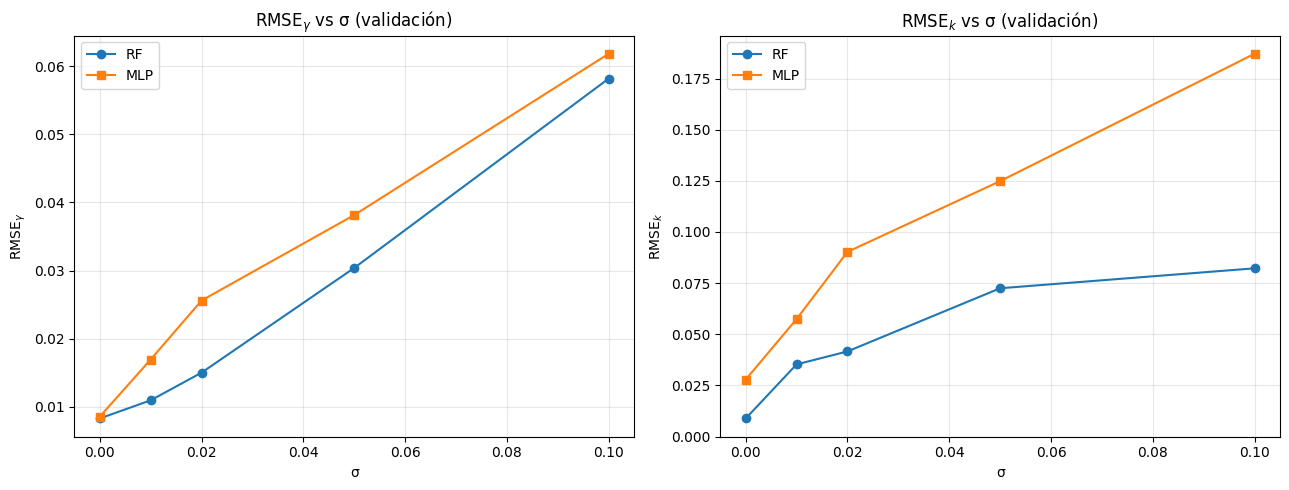

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(sigmas, resultados['RF']['g_te'],  'o-', label='RF')
ax[0].plot(sigmas, resultados['MLP']['g_te'], 's-', label='MLP')
ax[0].set_title(r'RMSE$_\gamma$ vs σ (validación)')
ax[0].set_xlabel('σ'); ax[0].set_ylabel(r'RMSE$_\gamma$'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(sigmas, resultados['RF']['k_te'],  'o-', label='RF')
ax[1].plot(sigmas, resultados['MLP']['k_te'], 's-', label='MLP')
ax[1].set_title(r'RMSE$_k$ vs σ (validación)')
ax[1].set_xlabel('σ'); ax[1].set_ylabel(r'RMSE$_k$'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

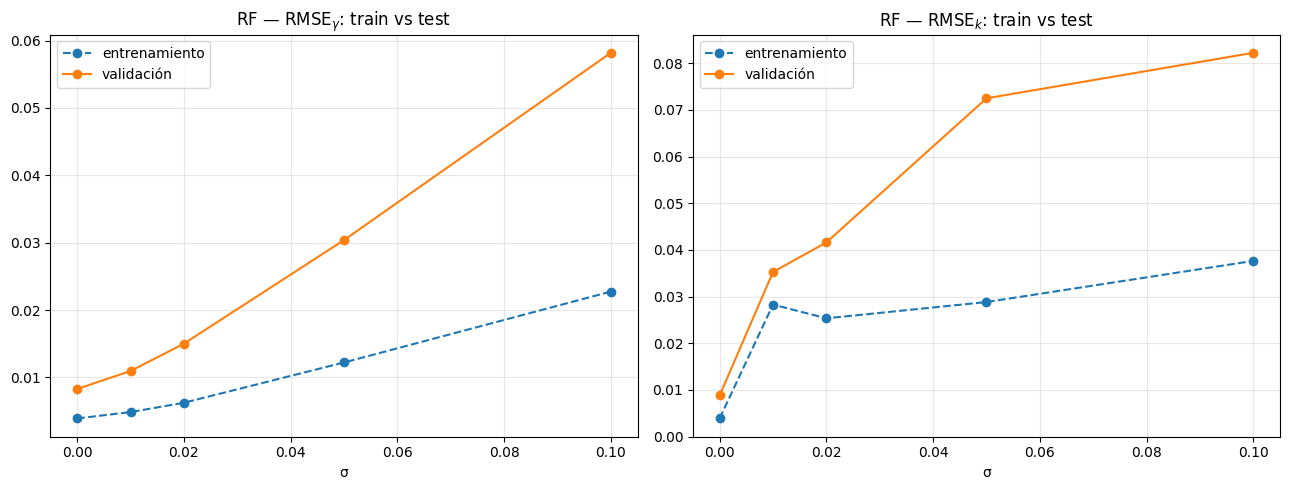

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(sigmas, resultados['RF']['g_tr'], 'o--', label='entrenamiento')
ax[0].plot(sigmas, resultados['RF']['g_te'], 'o-',  label='validación')
ax[0].set_title(r'RF — RMSE$_\gamma$: train vs test')
ax[0].set_xlabel('σ'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(sigmas, resultados['RF']['k_tr'], 'o--', label='entrenamiento')
ax[1].plot(sigmas, resultados['RF']['k_te'], 'o-',  label='validación')
ax[1].set_title(r'RF — RMSE$_k$: train vs test')
ax[1].set_xlabel('σ'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### d) Efecto del ruido y sobreajuste

Se repitió el entrenamiento para σ ∈ {0, 0.01, 0.02, 0.05, 0.10}, generando las señales limpias una sola vez y variando únicamente el ruido de medición. El RMSE de validación obtenido fue:

| σ    | RMSE<sub>γ</sub> (RF) | RMSE<sub>k</sub> (RF) | RMSE<sub>γ</sub> (MLP) | RMSE<sub>k</sub> (MLP) |
|------|:---------------------:|:---------------------:|:----------------------:|:----------------------:|
| 0.00 | 0.0083                | 0.0088                | 0.0085                 | 0.0279                 |
| 0.01 | 0.0109                | 0.0353                | 0.0169                 | 0.0574                 |
| 0.02 | 0.0150                | 0.0416                | 0.0256                 | 0.0903                 |
| 0.05 | 0.0304                | 0.0725                | 0.0382                 | 0.1249                 |
| 0.10 | 0.0582                | 0.0822                | 0.0618                 | 0.1871                 |

**Efecto del ruido.** El error crece de forma monótona con σ: a mayor ruido, menos información limpia contiene la señal y más difícil es recuperar los parámetros. Con σ = 0 (datos perfectos) el error es mínimo, y en ambos modelos crece de manera aproximadamente lineal con σ. El Random Forest se mantiene más preciso que el MLP en todo el rango.

**¿Qué parámetro es más difícil de inferir?** Hay que mirarlo con cuidado:

- En valor **absoluto**, RMSE<sub>k</sub> es mayor que RMSE<sub>γ</sub>. Pero esto es en parte un artefacto de escala: k recorre un rango más ancho ([1, 5], amplitud 4) que γ ([0.05, 1], amplitud ≈ 0.95).
- Al **normalizar por el rango de cada parámetro**, el error relativo de γ resulta mayor y crece más rápido con el ruido. Es decir, **el parámetro de amortiguamiento γ es el más difícil de inferir**. Por ejemplo, en σ = 0.10 el error relativo de γ es ≈ 6% de su rango, frente a ≈ 2% para k.

Esto tiene una explicación física clara. El parámetro k controla la **frecuencia** de oscilación (ω<sub>d</sub> ≈ √k), una característica muy robusta: aunque la señal tenga ruido, el período entre crestas se conserva y es fácil de medir. En cambio, γ controla la **tasa de decaimiento** de la envolvente e^(−γt/2); estimarla exige medir con precisión cómo disminuye la amplitud, algo que el ruido enmascara fácilmente, sobre todo a tiempos largos cuando la señal ya es pequeña y queda dominada por el ruido.

**Manifestación del sobreajuste.** Comparando el error de entrenamiento con el de validación del Random Forest:

| σ    | RMSE<sub>γ</sub> train | RMSE<sub>γ</sub> test | RMSE<sub>k</sub> train | RMSE<sub>k</sub> test |
|------|:----------------------:|:---------------------:|:----------------------:|:---------------------:|
| 0.00 | 0.0040                 | 0.0083                | 0.0041                 | 0.0088                |
| 0.02 | 0.0065                 | 0.0150                | 0.0253                 | 0.0416                |
| 0.10 | 0.0233                 | 0.0582                | 0.0384                 | 0.0822                |

El error de **entrenamiento** se mantiene sistemáticamente por debajo del de **validación**, y la brecha entre ambos **se ensancha al aumentar σ**. Esta es precisamente la firma del **sobreajuste**: el Random Forest tiene suficiente capacidad para "memorizar" los datos de entrenamiento —incluido el ruido aleatorio particular de esas señales—, logrando un error bajo sobre ellos. Pero ese ruido memorizado es específico del conjunto de entrenamiento y no se repite en los datos nuevos, así que el error de validación queda más alto. Cuanto mayor es σ, más ruido hay disponible para memorizar y mayor es la brecha train–test.

La lección es que un error de entrenamiento pequeño **no** garantiza un buen modelo: lo que mide la calidad real es el error de validación, sobre datos no vistos. Por eso es imprescindible separar los datos en train y test.